# Normalizing Flow Model Validation

Interactive notebook for visualizing and validating normalizing flow models trained on FAIR Universe data.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from typing import List
import numpy as np
import torch
import os
import sys

from fair_universe_demo.models.classifier_datamodule import ClassifierDatamodule
from fair_universe_demo.tasks.histogram import HistogramTask
from fair_universe_demo.utils.selection import createJetData
from fair_universe_demo.tasks.plot import PlottingMixin

2026-04-23 13:00:22,774 - luigi-interface      - INFO     - Loaded []


## Configuration

In [2]:
# Global Configuration Variables
output_path = "../../runs/fair_universe_demo_fixed_normalization"
snapshot_path = f"{output_path}/dag_snapshot.json"
use_test_data = False
root_dir = {True: "./test_data/", False: os.getenv("FAIR_UNIVERSE_DATA")}[use_test_data]
plot_save_dir = f"{output_path}/plots/"

# Global data storage (will be populated in setup)
signal_data = None
bg_data = None
signal_logprobs = None
bg_logprobs = None
nf_model = None
model_name = None
device = "cuda" if torch.cuda.is_available() else "cpu"

## Setup and Data Loading

In [3]:
def load_models():
    """Load NF models from snapshot and prepare data for the first model."""
    global num_jets, nf_model, model_name
    
    # Parse snapshot to get NF models
    nf_ckpts, _ = HistogramTask.parse_snapshot(snapshot_path)
    nf_models = ClassifierDatamodule.load_nf_models(nf_ckpts)
    
    # Get the first model only
    model_name, nf_model = list(nf_models.items())[0]
    print(f"Loading model: {model_name}")
    
    nf_model = nf_model.to(device).eval()
    
    os.makedirs(plot_save_dir, exist_ok=True)
    
    # Extract jet count from model name (e.g., "nf_signal_1jet&c_0p5" -> 1 or 2)
    name_parts = model_name.split('&')[0]  # "nf_signal_1jet" or "nf_background_2jet"
    if '1jet' in name_parts:
        num_jets = 1
    elif '2jet' in name_parts:
        num_jets = 2
    else:
        raise ValueError(f"Could not extract jet count from model name: {model_name}")

load_models()

Loading model: nf_signal_1jet&c_0p5


In [4]:
def load_data():
    # Load validation data
    global signal_data, bg_data, signal_logprobs, bg_logprobs
    print(f"Loading validation data for {num_jets} jets...")
    data, detlabel, _, _ = createJetData(
        jet_num=num_jets,
        useTestData=False,
        seed=78,
        root_dir=root_dir,
    )
    
    # Split by signal (1) and background (0)
    signal_mask = detlabel == 1
    bg_mask = detlabel == 0
    
    signal_data = data[signal_mask]
    bg_data = data[bg_mask]
    
    # Evaluate model on both signal and background
    print("Evaluating model on signal and background data...")
    with torch.no_grad():
        signal_logprobs = nf_model(signal_data.to(device)).cpu().numpy()
        bg_logprobs = nf_model(bg_data.to(device)).cpu().numpy()
    
    print(f"Loaded {len(signal_logprobs)} signal and {len(bg_logprobs)} background samples")
    print(f"Signal log-probs: mean={np.mean(signal_logprobs):.3f}, std={np.std(signal_logprobs):.3f}")
    print(f"Background log-probs: mean={np.mean(bg_logprobs):.3f}, std={np.std(bg_logprobs):.3f}")

load_data()

2026-04-23 13:00:24,691 - FAIR-Universe-Data   - INFO     - Opening file /work/kschmidt/NEEDLE/merged/FAIR_Universe_HiggsML_data.parquet


Loading validation data for 1 jets...


Loading data from parquet file: 100%|██████████| 210/210 [00:17<00:00, 12.15row_groups/s]


Evaluating model on signal and background data...
Loaded 471659 signal and 603243 background samples
Signal log-probs: mean=-2.077, std=7.605
Background log-probs: mean=-9.869, std=27.132


## Plot 1: Log-Probability Distributions

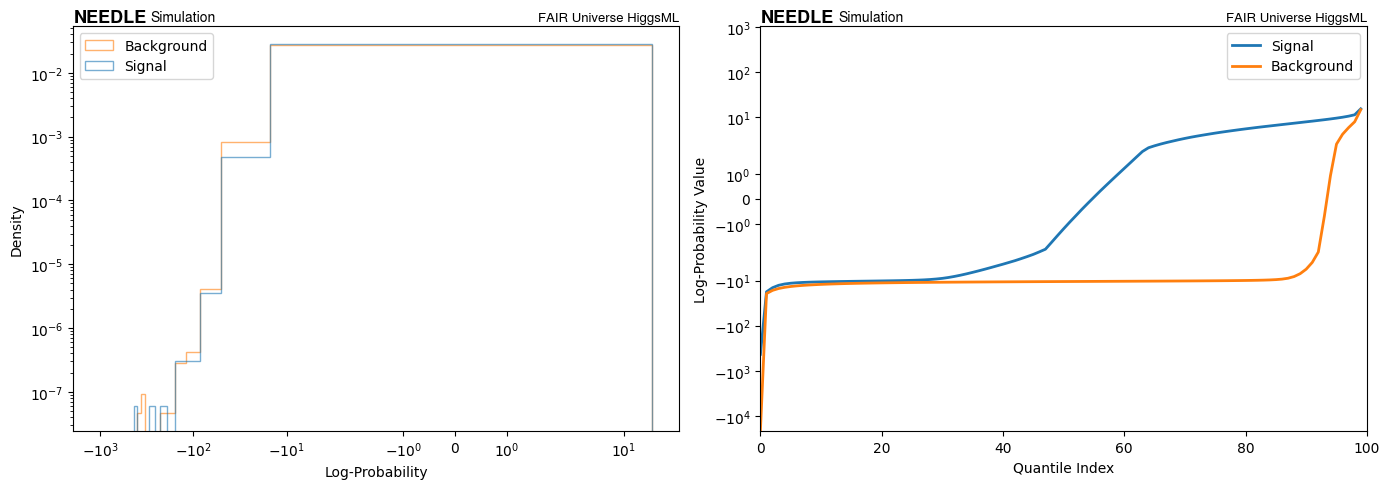

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram comparison
bins = np.linspace(-1000, 20, 30)
axes[0].hist([signal_logprobs, bg_logprobs], bins=bins, alpha=0.6, label=['Signal', "Background"], density=True, histtype="step")
axes[0].set_xlabel('Log-Probability')
axes[0].set_ylabel('Density')
axes[0].set_xscale("symlog")
axes[0].set_yscale("log")
axes[0].legend()

# Quantile comparison
q_sig = np.quantile(signal_logprobs, np.linspace(0, 1, 100))
q_bg = np.quantile(bg_logprobs, np.linspace(0, 1, 100))
axes[1].plot(q_sig, label='Signal', linewidth=2)
axes[1].plot(q_bg, label='Background', linewidth=2)
axes[1].set_xlabel('Quantile Index')
axes[1].set_ylabel('Log-Probability Value')
axes[1].legend()
axes[1].set_xlim(0, 100)
axes[1].set_yscale("symlog")

plt.tight_layout()

fig = PlottingMixin.set_needle_plot_style(fig)

plt.show()

## Plot 2: Log-Probability Statistics

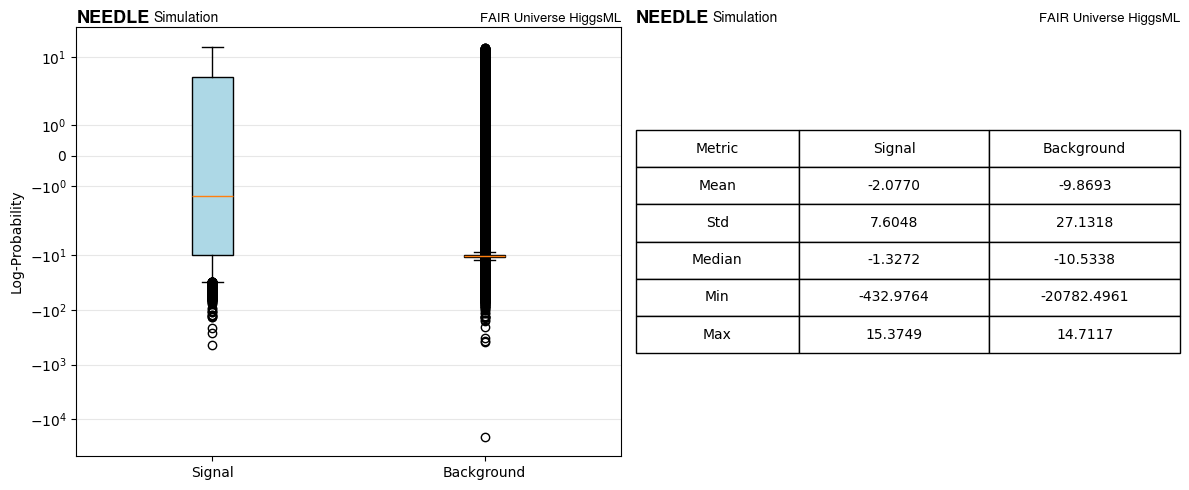

[['Metric', 'Signal', 'Background'], ['Mean', '-2.0770', '-9.8693'], ['Std', '7.6048', '27.1318'], ['Median', '-1.3272', '-10.5338'], ['Min', '-432.9764', '-20782.4961'], ['Max', '15.3749', '14.7117']]


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot
data_to_plot = [signal_logprobs, bg_logprobs]
bp = axes[0].boxplot(data_to_plot, tick_labels=['Signal', 'Background'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightcoral']):
    patch.set_facecolor(color)
axes[0].set_ylabel('Log-Probability')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_yscale("symlog")

# Statistics table
stats = {
    'Signal': {
        'Mean': np.mean(signal_logprobs),
        'Std': np.std(signal_logprobs),
        'Median': np.median(signal_logprobs),
        'Min': np.min(signal_logprobs),
        'Max': np.max(signal_logprobs),
    },
    'Background': {
        'Mean': np.mean(bg_logprobs),
        'Std': np.std(bg_logprobs),
        'Median': np.median(bg_logprobs),
        'Min': np.min(bg_logprobs),
        'Max': np.max(bg_logprobs),
    },
}

axes[1].axis('off')
table_data = [['Metric', 'Signal', 'Background']]
for metric in ['Mean', 'Std', 'Median', 'Min', 'Max']:
    table_data.append([
        metric,
        f"{stats['Signal'][metric]:.4f}",
        f"{stats['Background'][metric]:.4f}",
    ])

table = axes[1].table(
    table_data,
    cellLoc='center',
    loc='center',
    colWidths=[0.3, 0.35, 0.35],
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

plt.tight_layout()
fig = PlottingMixin.set_needle_plot_style(fig)
plt.show()
print(table_data)


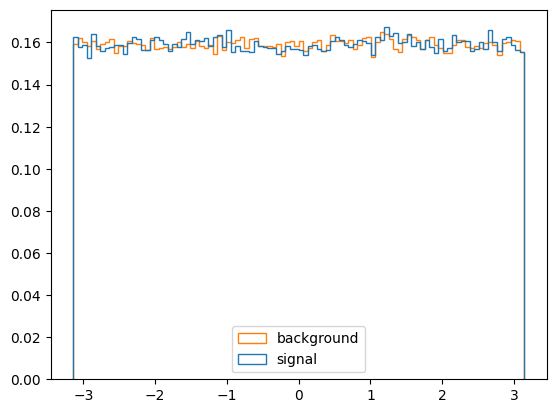

In [7]:
sig_data_np = signal_data.cpu().numpy()
bg_data_np = bg_data.cpu().numpy()
feature_index = 11
plt.hist([sig_data_np[..., feature_index], bg_data_np[..., feature_index]], bins=100, label=["signal", "background"], histtype="step", density=True)
# plt.xscale("log")
plt.legend()
plt.show()

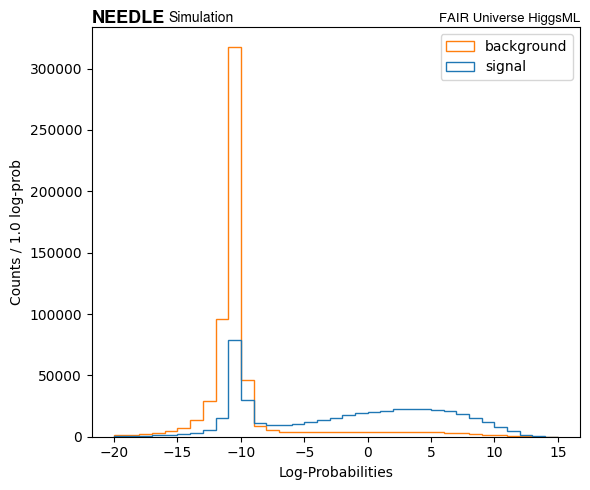

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
bins = np.linspace(-20, 15, 35+1)
plt.hist([signal_logprobs, bg_logprobs], bins=bins, label=["signal", "background"], histtype="step")
plt.legend()
plt.xlabel("Log-Probabilities")
plt.ylabel(f"Counts / {(bins[1]-bins[0])} log-prob")
PlottingMixin.set_needle_plot_style(fig)
plt.show()

## Plot 3: Log-Probability vs Feature

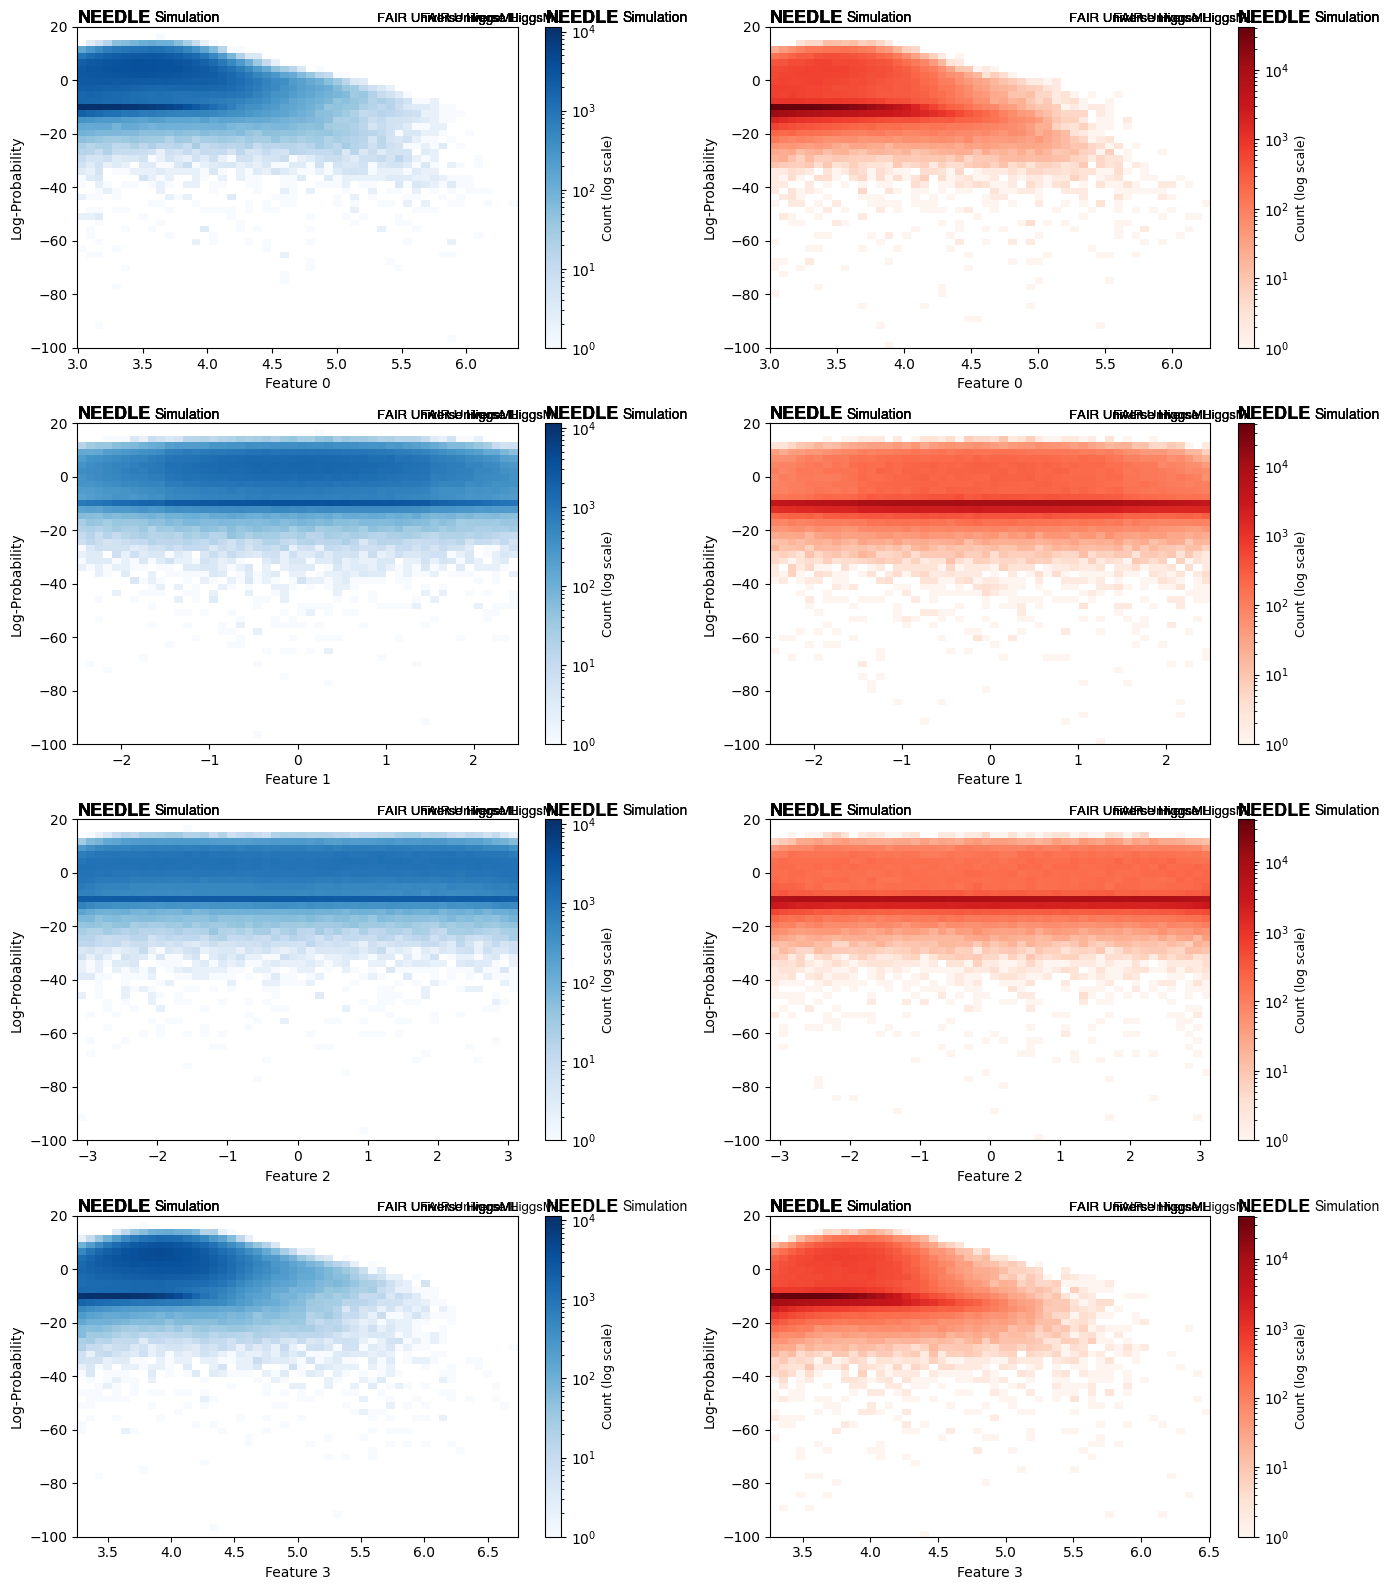

Saved: ../../runs/fair_universe_demo_fixed_normalization/plots/nf_signal_1jet&c_0p5_log_prob_vs_feature.png


In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

# Define y-range for binning
y_min, y_max = -100, 20

# Filter data to the specified y-range
sig_mask = (signal_logprobs >= y_min) & (signal_logprobs <= y_max)
bg_mask = (bg_logprobs >= y_min) & (bg_logprobs <= y_max)

sig_data_filtered = sig_data_np[sig_mask]
sig_logprobs_filtered = signal_logprobs[sig_mask]
bg_data_filtered = bg_data_np[bg_mask]
bg_logprobs_filtered = bg_logprobs[bg_mask]

# Get common scale for colorbars
vmin = 1  # Avoid log(0)
vmax_sig = 0
vmax_bg = 0

for i in range(4):
    h_sig, _, _ = np.histogram2d(
        sig_data_filtered[:, i],
        sig_logprobs_filtered,
        bins=50,
        range=[[sig_data_filtered[:, i].min(), sig_data_filtered[:, i].max()], [y_min, y_max]],
    )
    h_bg, _, _ = np.histogram2d(
        bg_data_filtered[:, i],
        bg_logprobs_filtered,
        bins=50,
        range=[[bg_data_filtered[:, i].min(), bg_data_filtered[:, i].max()], [y_min, y_max]],
    )
    vmax_sig = max(vmax_sig, h_sig.max())
    vmax_bg = max(vmax_bg, h_bg.max())

for i in range(4):
    # Signal heatmap (left)
    x_min_sig, x_max_sig = sig_data_filtered[:, i].min(), sig_data_filtered[:, i].max()
    h_sig, xedges, yedges = np.histogram2d(
        sig_data_filtered[:, i], sig_logprobs_filtered, bins=50, range=[[x_min_sig, x_max_sig], [y_min, y_max]]
    )
    im_sig = axes[i, 0].imshow(
        h_sig.T,
        origin="lower",
        aspect="auto",
        cmap="Blues",
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        norm=LogNorm(vmin=vmin, vmax=vmax_sig),
    )
    axes[i, 0].set_xlabel(f"Feature {i}", fontsize=10)
    axes[i, 0].set_ylabel("Log-Probability", fontsize=10)
    axes[i, 0].set_ylim(y_min, y_max)
    cbar_sig = plt.colorbar(im_sig, ax=axes[i, 0])
    cbar_sig.set_label("Count (log scale)", fontsize=9)

    # Background heatmap (right)
    x_min_bg, x_max_bg = bg_data_filtered[:, i].min(), bg_data_filtered[:, i].max()
    h_bg, xedges, yedges = np.histogram2d(
        bg_data_filtered[:, i], bg_logprobs_filtered, bins=50, range=[[x_min_bg, x_max_bg], [y_min, y_max]]
    )
    im_bg = axes[i, 1].imshow(
        h_bg.T,
        origin="lower",
        aspect="auto",
        cmap="Reds",
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        norm=LogNorm(vmin=vmin, vmax=vmax_bg),
    )
    axes[i, 1].set_xlabel(f"Feature {i}", fontsize=10)
    axes[i, 1].set_ylabel("Log-Probability", fontsize=10)
    axes[i, 1].set_ylim(y_min, y_max)
    cbar_bg = plt.colorbar(im_bg, ax=axes[i, 1])
    cbar_bg.set_label("Count (log scale)", fontsize=9)
    fig = PlottingMixin.set_needle_plot_style(fig, axes=axes.flatten().tolist())

plt.tight_layout()
plt.show()

# Save figure
fig_path = os.path.join(plot_save_dir, f"{model_name}_log_prob_vs_feature.png")
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved: {fig_path}")

## Plot 5: Calibration Curve (ROC)

In [10]:
bg_logprobs

array([-11.25784  , -14.885424 , -10.83115  , ..., -10.9160185,
        -8.39448  , -14.658068 ], shape=(603243,), dtype=float32)

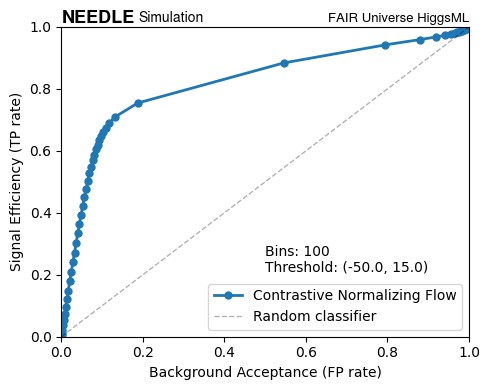

Saved: ../../runs/fair_universe_demo_fixed_normalization/plots/nf_signal_1jet&c_0p5_calibration_curve.png


In [11]:
num_bins = 100
thresholds = np.linspace(
    -50,
    15,
    num_bins,
)

sig_eff = []  # Fraction of signal above threshold (true positive rate)
bg_acc = []   # Fraction of background above threshold (false positive rate)

for thresh in thresholds:
    sig_eff.append(np.mean(signal_logprobs > thresh))
    bg_acc.append(np.mean(bg_logprobs > thresh))

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(
    bg_acc,
    sig_eff,
    linewidth=2,
    marker='o',
    markersize=5,
    label="Contrastive Normalizing Flow",
)
ax.set_xlabel('Background Acceptance (FP rate)')
ax.set_ylabel('Signal Efficiency (TP rate)')
ax.set_xlim(*[0, 1])
ax.set_ylim(*[0, 1])

# Diagonal reference line
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1, label='Random classifier')
ax.legend()

ax.text(
    0.5, 0.20, f"Bins: {num_bins}\nThreshold: ({thresholds.min()}, {thresholds.max()})",
    transform=ax.transAxes,          # use axes coordinates (0–1)
    ha="left",
    va="bottom",         # anchor text to lower right
)

plt.tight_layout()
fig = PlottingMixin.set_needle_plot_style(fig)
plt.show()

# Save figure
fig_path = os.path.join(plot_save_dir, f"{model_name}_calibration_curve.png")
#fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"Saved: {fig_path}")

In [12]:
print(bg_acc)
print(sig_eff)

[np.float64(0.9998159945494601), np.float64(0.999812679135937), np.float64(0.9998060483088904), np.float64(0.9997977597750823), np.float64(0.9997828404142277), np.float64(0.9997712364668965), np.float64(0.9997596325195651), np.float64(0.9997513439857569), np.float64(0.9997364246249024), np.float64(0.9997248206775711), np.float64(0.9997148744370014), np.float64(0.9996982973693851), np.float64(0.9996833780085306), np.float64(0.9996618278206295), np.float64(0.9996435930462517), np.float64(0.999620385151589), np.float64(0.999598834963688), np.float64(0.9995739693622636), np.float64(0.9995457883473161), np.float64(0.9995060033850373), np.float64(0.9994745069565665), np.float64(0.9994347219942875), np.float64(0.9993883062049622), np.float64(0.9993402327088752), np.float64(0.9993037631601196), np.float64(0.9992540319572709), np.float64(0.9991960122206143), np.float64(0.9991297039501494), np.float64(0.9990418454917835), np.float64(0.9989208328981853), np.float64(0.9988014780113487), np.float64

## Plot 6: Feature Distributions

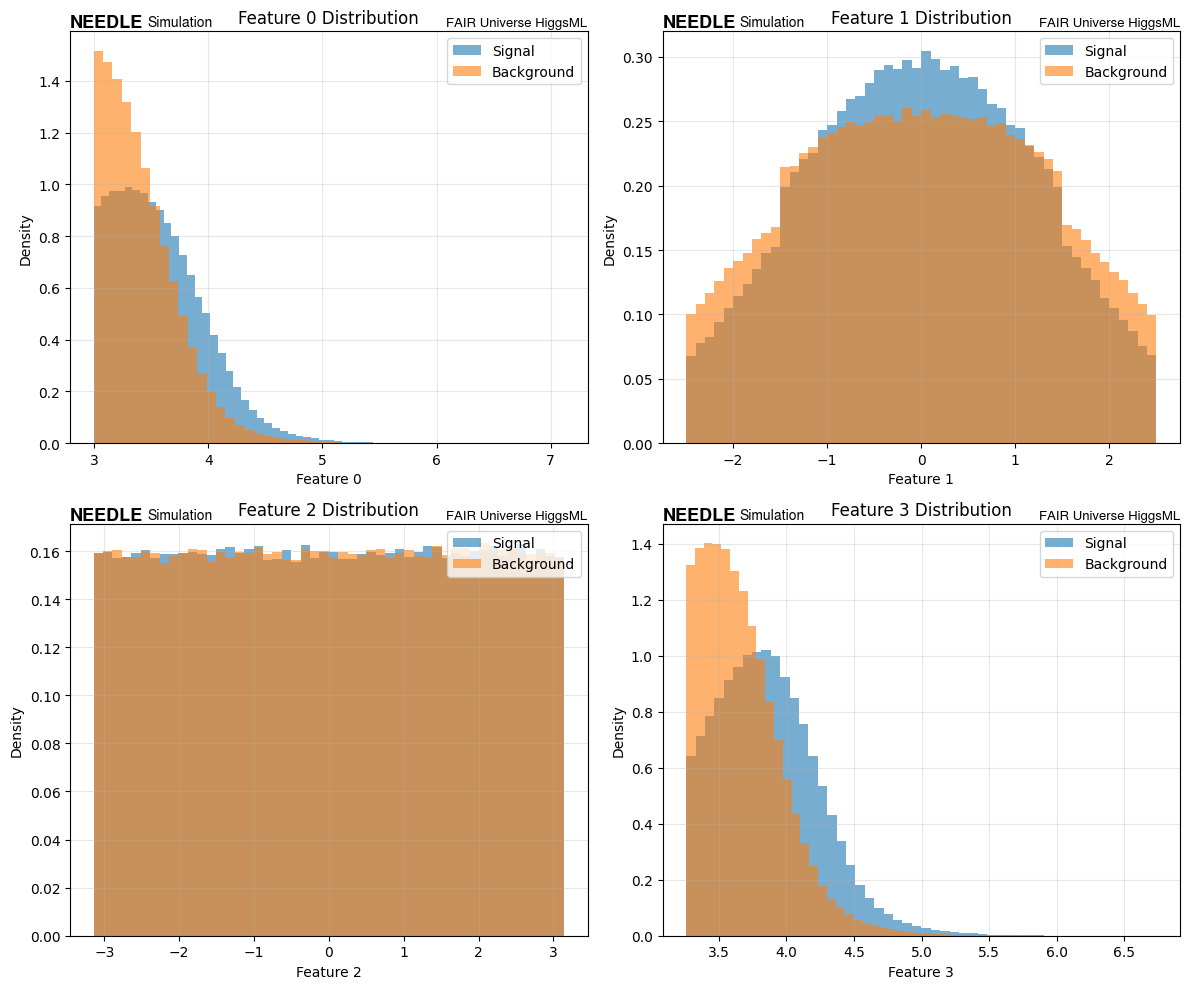

Saved: ../../runs/fair_universe_demo_fixed_normalization/plots/nf_signal_1jet&c_0p5_feature_distribution.png

All plots saved to: ../../runs/fair_universe_demo_fixed_normalization/plots/


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

sig_data_np = signal_data.cpu().numpy()
bg_data_np = bg_data.cpu().numpy()

for i in range(min(4, 4)):
    axes[i].hist(sig_data_np[:, i], bins=50, alpha=0.6, label='Signal', density=True)
    axes[i].hist(bg_data_np[:, i], bins=50, alpha=0.6, label='Background', density=True)
    axes[i].set_xlabel(f'Feature {i}')
    axes[i].set_ylabel('Density')
    axes[i].set_title(f'Feature {i} Distribution')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

fig = PlottingMixin.set_needle_plot_style(fig)
plt.tight_layout()
plt.show()

# Save figure
fig_path = os.path.join(plot_save_dir, f"{model_name}_feature_distribution.png")
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"Saved: {fig_path}")
print(f"\nAll plots saved to: {plot_save_dir}")

## Deep Diagnosis

In [14]:
"""
Deep diagnostics for NF forward pass - debug individual components.

Generated using Claude Haiku 4.5
"""

import torch
import numpy as np
from typing import Tuple, Dict


def diagnose_forward_pass(
    model,
    signal_batch: torch.Tensor,
    bg_batch: torch.Tensor,
    device: str = "cpu",
) -> Dict[str, np.ndarray]:
  """Decompose NF forward pass into components to find where issues arise.
  
  Args:
    model: ConditionalNormalizingFlowModule
    signal_batch: Signal data (n_sig, n_features)
    bg_batch: Background data (n_bg, n_features)
    device: Device to run on
  
  Returns:
    Dictionary with component breakdowns
  """
  model = model.to(device)
  model.eval()
  
  signal_batch = signal_batch.to(device)
  bg_batch = bg_batch.to(device)
  
  results = {}
  
  with torch.no_grad():
      # Step 1: Normalization
      signal_norm = (signal_batch - model.x_mean) / model.x_std
      bg_norm = (bg_batch - model.x_mean) / model.x_std
      
      results['signal_norm_mean'] = signal_norm.mean(dim=0).cpu().numpy()
      results['signal_norm_std'] = signal_norm.std(dim=0).cpu().numpy()
      results['bg_norm_mean'] = bg_norm.mean(dim=0).cpu().numpy()
      results['bg_norm_std'] = bg_norm.std(dim=0).cpu().numpy()
      
      print("=" * 80)
      print("STEP 1: NORMALIZATION CHECK")
      print("=" * 80)
      print(f"Signal normalized: mean={signal_norm.mean():.4f}, std={signal_norm.std():.4f}")
      print(f"Background normalized: mean={bg_norm.mean():.4f}, std={bg_norm.std():.4f}")
      print(f"(Both should be ~mean=0, std=1)")
      
      # Step 2: Flow forward pass
      z_sig, logdet_sig = model.flow(signal_norm)
      z_bg, logdet_bg = model.flow(bg_norm)
      
      print("\n" + "=" * 80)
      print("STEP 2: FLOW OUTPUT (z and log_det)")
      print("=" * 80)
      
      print(f"\nSignal z:")
      print(f"  Mean: {z_sig.mean():.4f}, Std: {z_sig.std():.4f}")
      print(f"  Min: {z_sig.min():.4f}, Max: {z_sig.max():.4f}")
      print(f"  NaNs: {z_sig.isnan().sum()}, Infs: {z_sig.isinf().sum()}")
      
      print(f"\nBackground z:")
      print(f"  Mean: {z_bg.mean():.4f}, Std: {z_bg.std():.4f}")
      print(f"  Min: {z_bg.min():.4f}, Max: {z_bg.max():.4f}")
      print(f"  NaNs: {z_bg.isnan().sum()}, Infs: {z_bg.isinf().sum()}")
      
      results['z_sig'] = z_sig.cpu().numpy()
      results['z_bg'] = z_bg.cpu().numpy()
      
      print(f"\nSignal log_det:")
      print(f"  Mean: {logdet_sig.mean():.4f}, Std: {logdet_sig.std():.4f}")
      print(f"  Min: {logdet_sig.min():.4f}, Max: {logdet_sig.max():.4f}")
      print(f"  NaNs: {logdet_sig.isnan().sum()}, Infs: {logdet_sig.isinf().sum()}")
      
      print(f"\nBackground log_det:")
      print(f"  Mean: {logdet_bg.mean():.4f}, Std: {logdet_bg.std():.4f}")
      print(f"  Min: {logdet_bg.min():.4f}, Max: {logdet_bg.max():.4f}")
      print(f"  NaNs: {logdet_bg.isnan().sum()}, Infs: {logdet_bg.isinf().sum()}")
      
      results['logdet_sig'] = logdet_sig.cpu().numpy()
      results['logdet_bg'] = logdet_bg.cpu().numpy()
      
      # Step 3: NaN handling
      z_sig_handled = torch.nan_to_num(z_sig, nan=0.0, posinf=1e3, neginf=-1e3)
      z_bg_handled = torch.nan_to_num(z_bg, nan=0.0, posinf=1e3, neginf=-1e3)
      
      print("\n" + "=" * 80)
      print("STEP 3: NAN HANDLING")
      print("=" * 80)
      print(f"Signal z changed: {(z_sig != z_sig_handled).sum()} values")
      print(f"Background z changed: {(z_bg != z_bg_handled).sum()} values")
      
      # Step 4: Prior log prob
      log_z_sig = model.prior.log_prob(z_sig_handled).sum(dim=1)
      log_z_bg = model.prior.log_prob(z_bg_handled).sum(dim=1)
      
      print("\n" + "=" * 80)
      print("STEP 4: PRIOR LOG-PROB (sum over features)")
      print("=" * 80)
      print(f"Signal log_z:")
      print(f"  Mean: {log_z_sig.mean():.4f}, Std: {log_z_sig.std():.4f}")
      print(f"  Min: {log_z_sig.min():.4f}, Max: {log_z_sig.max():.4f}")
      
      print(f"\nBackground log_z:")
      print(f"  Mean: {log_z_bg.mean():.4f}, Std: {log_z_bg.std():.4f}")
      print(f"  Min: {log_z_bg.min():.4f}, Max: {log_z_bg.max():.4f}")
      
      results['log_z_sig'] = log_z_sig.cpu().numpy()
      results['log_z_bg'] = log_z_bg.cpu().numpy()
      
      # Step 5: Final log-prob
      log_prob_sig = log_z_sig + logdet_sig
      log_prob_bg = log_z_bg + logdet_bg
      
      print("\n" + "=" * 80)
      print("STEP 5: FINAL LOG-PROB (log_z + log_det)")
      print("=" * 80)
      print(f"Signal log_prob:")
      print(f"  Mean: {log_prob_sig.mean():.4f}, Std: {log_prob_sig.std():.4f}")
      print(f"  Min: {log_prob_sig.min():.4f}, Max: {log_prob_sig.max():.4f}")
      
      print(f"\nBackground log_prob:")
      print(f"  Mean: {log_prob_bg.mean():.4f}, Std: {log_prob_bg.std():.4f}")
      print(f"  Min: {log_prob_bg.min():.4f}, Max: {log_prob_bg.max():.4f}")
      
      results['log_prob_sig'] = log_prob_sig.cpu().numpy()
      results['log_prob_bg'] = log_prob_bg.cpu().numpy()
  
  # Summary diagnostics
  print("\n" + "=" * 80)
  print("DIAGNOSIS")
  print("=" * 80)
  
  # Check where the problem is
  sig_logdet_ok = (logdet_sig.abs() < 1000).all()
  bg_logdet_ok = (logdet_bg.abs() < 1000).all()
  
  sig_logz_ok = (log_z_sig.abs() < 100).all()
  bg_logz_ok = (log_z_bg.abs() < 100).all()
  
  if not bg_logdet_ok:
      print("⚠️  PROBLEM IDENTIFIED: log_det diverging for background")
      print(f"    {(logdet_bg < -1000).sum()} background samples have log_det < -1000")
      print("    → Background features likely out-of-distribution")
      print("    → Flow has not learned their geometry properly")
  
  if not bg_logz_ok:
      print("⚠️  PROBLEM IDENTIFIED: log_z diverging for background")
      print(f"    {(log_z_bg < -100).sum()} background samples have log_z < -100")
      print("    → z values extreme after flow (not ~Normal(0,1))")
  
  if sig_logdet_ok and bg_logdet_ok and sig_logz_ok and bg_logz_ok:
      print("✓ Components look reasonable individually")
      print("  But combined, something is off. Check:")
      print("  - Are signal and background trained data the same?")
      print("  - Is X_mean/X_std computed consistently?")
  
  return results

results = diagnose_forward_pass(
    nf_model,
    signal_data,
    bg_data,
    device="cuda"
)

STEP 1: NORMALIZATION CHECK
Signal normalized: mean=0.0000, std=1.0000
Background normalized: mean=-0.1964, std=0.9654
(Both should be ~mean=0, std=1)

STEP 2: FLOW OUTPUT (z and log_det)

Signal z:
  Mean: -0.0708, Std: 0.9057
  Min: -28.6697, Max: 9.8543
  NaNs: 0, Infs: 0

Background z:
  Mean: -0.2007, Std: 0.9013
  Min: -203.2747, Max: 22.7280
  NaNs: 0, Infs: 0

Signal log_det:
  Mean: 24.5547, Std: 6.3031
  Min: -7.6000, Max: 36.8800
  NaNs: 0, Infs: 0

Background log_det:
  Mean: 17.0352, Std: 4.1268
  Min: -7.1634, Max: 36.8458
  NaNs: 0, Infs: 0

STEP 3: NAN HANDLING
Signal z changed: 0 values
Background z changed: 0 values

STEP 4: PRIOR LOG-PROB (sum over features)
Signal log_z:
  Mean: -26.6317, Std: 3.2914
  Min: -447.3178, Max: -19.3861

Background log_z:
  Mean: -26.9045, Std: 26.8767
  Min: -20782.1992, Max: -19.6018

STEP 5: FINAL LOG-PROB (log_z + log_det)
Signal log_prob:
  Mean: -2.0770, Std: 7.6048
  Min: -432.9764, Max: 15.3749

Background log_prob:
  Mean: -9.86

## ROC with filtered data



In [15]:
from fair_universe_demo.models.nf_datamodule import NormalizingFlowDatamodule

nf_datamodule = NormalizingFlowDatamodule(
    train_on_signal=True,
    num_jets=1,
    root_dir=root_dir,
)
nf_datamodule.setup()

print(f"Model X_mean: {nf_model.x_mean}")
print(f"Model X_std: {nf_model.x_std}")
print(f"Datamodule X_mean: {nf_datamodule.X_mean}")
print(f"Datamodule X_std: {nf_datamodule.X_std}")

2026-04-23 13:03:35,303 - FAIR-Universe-Data   - INFO     - Opening file /work/kschmidt/NEEDLE/merged/FAIR_Universe_HiggsML_data.parquet
Loading data from parquet file: 100%|██████████| 210/210 [00:17<00:00, 12.15row_groups/s]


Model X_mean: tensor([ 3.5730e+00,  2.7012e-03,  2.1554e-03,  3.8697e+00,  1.6073e-03,
         1.1989e-03,  3.9663e+00,  7.6108e-04, -4.7871e-03,  3.9663e+00,
         3.2369e+00,  2.2093e-03,  2.3168e+01,  4.3950e+00,  3.9257e+00,
         2.4950e+00,  2.7291e+00,  4.9710e+00,  8.7449e-01,  6.7118e-01],
       device='cuda:0')
Model X_std: tensor([ 0.3984,  1.1647,  1.8139,  0.3756,  1.1883,  1.8144,  0.5841,  2.1553,
         1.8096,  0.5841,  0.7863,  1.8136, 23.6252,  0.2449,  0.7232,  0.5856,
         0.7077,  0.3603,  0.5665,  0.9762], device='cuda:0')
Datamodule X_mean: tensor([ 3.5730e+00,  2.7012e-03,  2.1554e-03,  3.8697e+00,  1.6073e-03,
         1.1989e-03,  3.9663e+00,  7.6108e-04, -4.7871e-03,  3.9663e+00,
         3.2369e+00,  2.2093e-03,  2.3168e+01,  4.3950e+00,  3.9257e+00,
         2.4950e+00,  2.7291e+00,  4.9710e+00,  8.7449e-01,  6.7118e-01])
Datamodule X_std: tensor([ 0.3984,  1.1647,  1.8139,  0.3756,  1.1883,  1.8144,  0.5841,  2.1553,
         1.8096,  0.5841

/work/kschmidt/NEEDLE/orchestrator/examples/fair_universe_demo/fair_universe_demo/models/nf_datamodule.py:70: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  S_tensor = torch.tensor(j2_data[j2_detlabel == 1], dtype=torch.float32)
/work/kschmidt/NEEDLE/orchestrator/examples/fair_universe_demo/fair_universe_demo/models/nf_datamodule.py:71: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  BG_tensor = torch.tensor(j2_data[j2_detlabel == 0], dtype=torch.float32)
